#### Name: Sutton Ursillo

# PHYS 230 Lab Assignment 18

### Monday, April 13, 2026: Chapter 10.2
- Monte Carlo Integration 

In [2]:
# import statements here
import numpy as np
import matplotlib.pyplot as plt
import random 

## The problem: let's use Monte Carlo methods to evaluate the integral below. 
$$ f(x) = -x^3 +6x^2 -x+17 $$
over the range of $ -2 \leq x \leq 5$

## Part 1: "Hit-or-miss" Monte Carlo Method 

#### Step 1: Make a plot of the function to get an idea of what it looks like. 

(**Hint:** After plotting, look at the $y$-axis and determine a reasonable $y_{\text{max}}$ for the axis limit and limit the axis between 0 and this determined value. This will help to define your area for the method.)

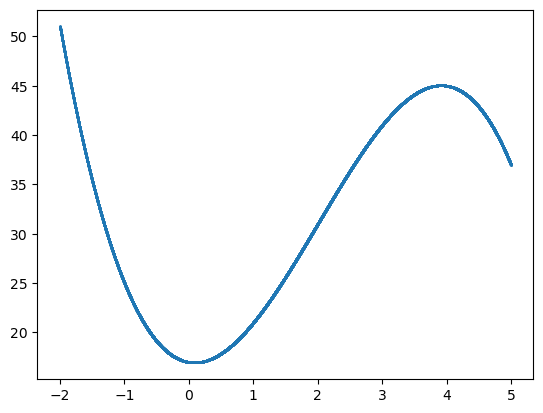

In [31]:
def f(x):
    return -x**3 + 6*x**2 - x+17

N = 10000
xpts = np.linspace(-2,5,N)
ypts = f(xpts)

plt.scatter(xpts,ypts, s=1)
plt.show()

From this graph the $y_{max}$ is 53.

#### Step 2: Use your graph from step 1 to define the area over which you're evaluating your integral, and apply the "hit-or-miss" method of Monte Carlo integration for 10,000 points. Be sure to run the code a few times to get a sense of the average value returned. 

In [107]:
#number of points
N=10000
#area
A = 7*53
#counter
k = 0

for i in range(N):
    x = 7*random.random()
    y = 53*random.random()
    if y < f(x):
        k += 1

I = (k*A)/N

print("I=", I)

I= 193.6249


After running the code a couple times I got values from 190 to 198

#### Step 3: You can fairly easily solve this integral by hand. Using code, evaluate the true integral below and compare it to your result from step 2.  

evaluating the integral by hand,

$$f(x) = (\frac{-x^4}{4} + 2x^3 - \frac{x^2}{2}+17x)|_{-2}^5$$

$$ (\frac{-5^4}{4} + 250 - 12.5 + 85) - (\frac{2^4}{4} - 16 +2 - 34)$$

$$ 166 - (-44) = 210  $$

In [ ]:
#using the trapezoidal method
#limits
a = -2
b = 5 
N = 10

#step size h
h = (b-a)/N

#integrating
s = 0.5*f(a)+0.5*f(b)
for k in range(1,N):
    s += f(a+k*h)
I_new = h*s

print("I =", I_new)

I = 223.10750000000002


These results were off from what the hit or miss method predicted. I know my hand calculation is off somehwere I am just not sure where I messed up. 

#### Step 4: Try evaluating again using both fewer and more points (make sure you show both results). What do you notice about your result? What do you notice about these different results as you run the code multiple times? [To be really complete, try running for a variety of fewer and more points]

In [89]:
def f(x):
    return -x**3 + 6*x**2 - x+17

N_vals = [10,100,1000,100000,1000000,10000000]

#area
A = 7*53

#calculating the value at different N values
for N in N_vals:
    k = 0
    for i in range(N):
        x = 7*random.random()
        y = 53*random.random()
        if y < f(x):
            k += 1

    I = (k*A)/N

    print("N=", N, "I =", I)




N= 10 I = 148.4
N= 100 I = 200.34
N= 1000 I = 186.242
N= 100000 I = 193.26874
N= 1000000 I = 193.775526
N= 10000000 I = 193.5263253


After running the code many times the results seem very random (which makes sense). Sometimes the lower N values have better results than the higher N values but it mostly follows the pattern where the greater the N the more accurate the result is. I think adjusting the y scale could be helpful or coding something to find the $y_{max}$.

## Part 2: Mean Value Method 

Let's evaluate the same integral using the mean value method instead. 

#### Step 1: Define the function `f(x)` of the integrand

In [81]:
def f(x):
    return -x**3 + 6*x**2 - x+17

#### Step 2: Create a a loop with $N=10,000$ points to solve for the integral using the mean value method. 

In [108]:
#points N
N = 10000
s = 0

for i in range(N):
    x = 7*random.random()
    s+= f(x)

I = (7/N)*s
print("I=", I)


I= 183.1910663855859


#### Step 3: In a markdown cell, compare these results with the "hit-or-miss" method from above. What can you conclude about accuracy? speed? To really evaluate this, be sure to run each method with the same number of points multiple times to see the variation in the result. 

These results from the mean value method are not as good as the hit-or-miss method. The hit-or-miss method is consistantly at 193ish and the mean value method is about 13 points lower from that. Running both many times at the same N value I was able to conclude this result. The speed is the same for both since they are running the same amount of points. I would say that the hit-or-miss method has a bigger variation with each run but that could also be the random function. 